# charge bibliotique

In [11]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import matplotlib.pyplot  as plt

##import data

In [12]:
#connexion:
load_dotenv()  # installer .env
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
db = os.getenv("DB_NAME")
DATABASE_URL = f"postgresql://{user}:{password}@{host}:{port}/{db}"
engine = create_engine(DATABASE_URL)
print("conexion ok")
df=pd.read_sql("select * from staging.products_raw",engine)

conexion ok


In [20]:
df.head()

,id,name,new_price,old_price,percent_discount,rate,verified_ratings,saler_score,Followers,Order Fulfillment_Rate,Quality Score,Customer Rating
0,0,Force 14-inch Laptop Daily Backpack For Unisex...,EGP 159.00,EGP 299.00,47%,4.2,757.0,100%,1085.0,Excellent,Excellent,Excellent
1,1,"Force Daily Backpack Laptop 14"" For Unisex - D...",EGP 159.00,EGP 245.00,35%,4.4,109.0,100%,1085.0,Excellent,Excellent,Excellent
2,2,Force 14-inch Laptop Daily Backpack For Unisex...,EGP 159.00,EGP 245.00,35%,4.3,134.0,100%,1085.0,Excellent,Excellent,Excellent
3,3,Force 14-inch Laptop Daily Backpack For Unisex...,EGP 159.00,EGP 245.00,35%,4.3,128.0,100%,1085.0,Excellent,Excellent,Excellent
4,4,"Force Daily Backpack Laptop 14"" For Unisex - Nod",EGP 159.00,EGP 245.00,35%,4.5,117.0,100%,1085.0,Excellent,Excellent,Excellent


In [21]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      2004 non-null   int64  
 1   name                    1998 non-null   object 
 2   new_price               1998 non-null   object 
 3   old_price               1512 non-null   object 
 4   percent_discount        1512 non-null   object 
 5   rate                    723 non-null    float64
 6   verified_ratings        723 non-null    float64
 7   saler_score             1963 non-null   object 
 8   Followers               1954 non-null   float64
 9   Order Fulfillment_Rate  1918 non-null   object 
 10  Quality Score           1918 non-null   object 
 11  Customer Rating         1483 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 188.0+ KB


In [22]:
df.describe(include="all")

,id,name,new_price,old_price,percent_discount,rate,verified_ratings,saler_score,Followers,Order Fulfillment_Rate,Quality Score,Customer Rating
count,2004.000000,1998,1998,1512,1512,723.000000,723.000000,1963,1954.000000,1918,1918,1483
unique,NaN,1764,918,646,82,NaN,NaN,16,NaN,6,5,5
top,NaN,TAT Laptop Sleeve Case Cover Bag – Multicolor,EGP 199.00,EGP 350.00,30%,NaN,NaN,100%,NaN,Excellent,Excellent,Excellent
freq,NaN,58,102,128,103,NaN,NaN,414,NaN,944,1020,971
mean,259.087325,NaN,NaN,NaN,NaN,4.284509,30.709544,NaN,640.208802,NaN,NaN,NaN
std,203.797742,NaN,NaN,NaN,NaN,0.797474,162.015188,NaN,1492.126808,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,100.000000,NaN,NaN,NaN,NaN,4.000000,1.000000,NaN,61.250000,NaN,NaN,NaN
50%,200.000000,NaN,NaN,NaN,NaN,4.400000,4.000000,NaN,151.000000,NaN,NaN,NaN
75%,365.250000,NaN,NaN,NaN,NaN,5.000000,14.500000,NaN,472.000000,NaN,NaN,NaN


In [23]:
df.shape

(2004, 12)

In [24]:
df.columns

Index(['id', 'name', 'new_price', 'old_price', 'percent_discount', 'rate',
       'verified_ratings', 'saler_score', 'Followers',
       'Order Fulfillment_Rate', 'Quality Score', 'Customer Rating'],
      dtype='object')

In [25]:
df.isnull().sum()

id                           0
name                         6
new_price                    6
old_price                  492
percent_discount           492
rate                      1281
verified_ratings          1281
saler_score                 41
Followers                   50
Order Fulfillment_Rate      86
Quality Score               86
Customer Rating            521
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.dtypes

id                          int64
name                       object
new_price                  object
old_price                  object
percent_discount           object
rate                      float64
verified_ratings          float64
saler_score                object
Followers                 float64
Order Fulfillment_Rate     object
Quality Score              object
Customer Rating            object
dtype: object

In [28]:
df.describe()

,id,rate,verified_ratings,Followers
count,2004.000000,723.000000,723.000000,1954.000000
mean,259.087325,4.284509,30.709544,640.208802
std,203.797742,0.797474,162.015188,1492.126808
min,0.000000,1.000000,1.000000,1.000000
25%,100.000000,4.000000,1.000000,61.250000
50%,200.000000,4.400000,4.000000,151.000000
75%,365.250000,5.000000,14.500000,472.000000
max,798.000000,5.000000,3211.000000,17224.000000


1. Distribution des prix

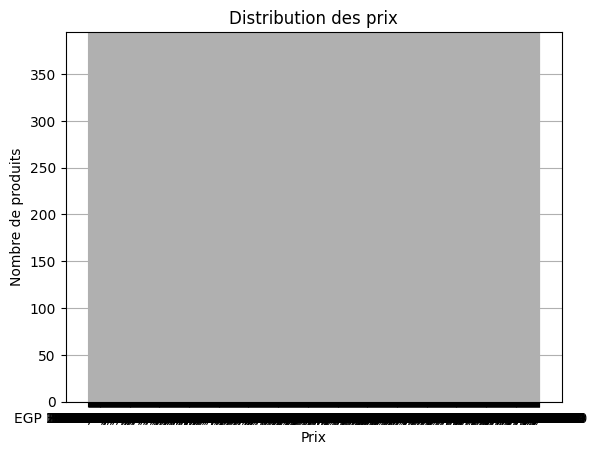

In [41]:
df["new_price"].hist(bins=20)
plt.title("Distribution des prix")
plt.xlabel("Prix")
plt.ylabel("Nombre de produits")
plt.show()

2. Distribution des notes

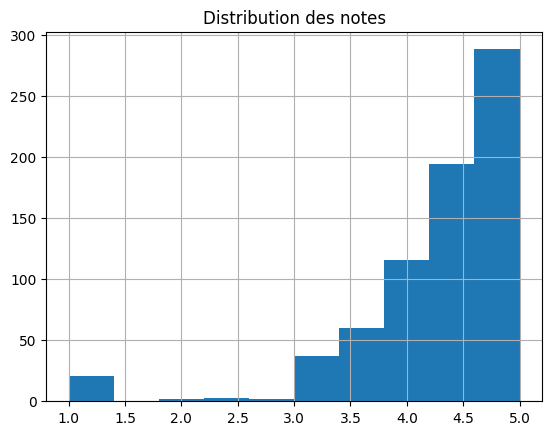

In [35]:
df["rate"].hist(bins=10)
plt.title("Distribution des notes")
plt.show()

3. Top 10 produits les plus chers

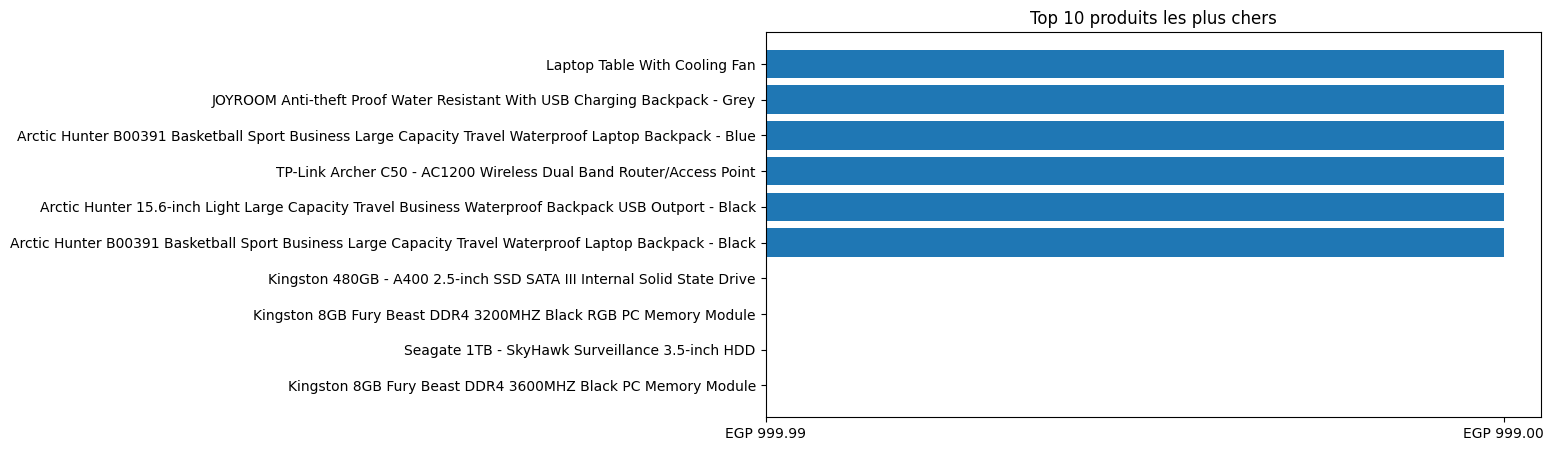

In [37]:
top = df.sort_values("new_price", ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh(top["name"], top["new_price"])
plt.title("Top 10 produits les plus chers")
plt.show()

4. Corrélation

In [38]:
numeric = df.select_dtypes(include="number")
numeric.corr()

,id,rate,verified_ratings,Followers
id,1.000000,0.008265,-0.044205,-0.007002
rate,0.008265,1.000000,0.005100,0.024943
verified_ratings,-0.044205,0.005100,1.000000,0.140531
Followers,-0.007002,0.024943,0.140531,1.000000
